# New Section

In [1]:
import pandas as  pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DL/Day17/online_retail_listing.csv",encoding="unicode_escape",delimiter=";")

In [6]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,1.12.2009 07:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.12.2009 07:45,"1,25",13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,4.12.2011 13:00,"8,25",14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,4.12.2011 13:00,"4,95",14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,4.12.2011 13:15,"1,65",16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,4.12.2011 13:15,"2,89",16931.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61743 entries, 0 to 61742
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      61743 non-null  object 
 1   StockCode    61743 non-null  object 
 2   Description  61424 non-null  object 
 3   Quantity     61743 non-null  int64  
 4   InvoiceDate  61743 non-null  object 
 5   Price        61742 non-null  object 
 6   Customer ID  42383 non-null  float64
 7   Country      61742 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 3.8+ MB


In [8]:
df.isna().sum()

Invoice            0
StockCode          0
Description      319
Quantity           0
InvoiceDate        0
Price              1
Customer ID    19360
Country            1
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [11]:
df.columns


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [12]:
df.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price           object
Customer ID    float64
Country         object
dtype: object

In [13]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,1.12.2009 07:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.12.2009 07:45,"1,25",13085.0,United Kingdom


In [15]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [16]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                  object
Customer ID           float64
Country                object
dtype: object

In [19]:
df['Price']=pd.to_numeric(df['Price'])

ValueError: Unable to parse string "6,95" at position 0

In [22]:
df['Price']=df['Price'].replace(",","",regex=True)

In [24]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                  object
Customer ID           float64
Country                object
dtype: object

In [25]:
df['Price']=pd.to_numeric(df['Price'])

In [26]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                   int64
Customer ID           float64
Country                object
dtype: object

In [36]:
df_Recency=df.groupby(by="Customer ID",as_index=False)["InvoiceDate"].max()

In [37]:
df_Recency

,Customer ID,InvoiceDate
0,12346.0,2011-01-18 10:17:00
1,12347.0,2011-10-31 12:25:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00
...,...,...
5919,18283.0,2011-11-30 12:59:00
5920,18284.0,2010-06-10 12:31:00
5921,18285.0,2010-02-17 10:24:00
5922,18286.0,2010-08-20 11:57:00


In [38]:
Recent_data=df_Recency["InvoiceDate"].max()

In [39]:
Recent_data

Timestamp('2010-12-01 17:24:00')

In [40]:
df_Recency['Recency']=df_Recency['InvoiceDate'].apply(lambda x:(Recent_data-x).days)

In [41]:
df_Recency

,Customer ID,InvoiceDate,Recency
0,12346.0,2010-04-01 09:53:00,244
1,12349.0,2009-04-12 12:49:00,598
2,12358.0,2009-08-12 07:59:00,476
3,12359.0,2009-12-16 15:39:00,350
4,12362.0,2009-01-12 10:10:00,688
...,...,...,...
1214,18271.0,2009-08-12 11:27:00,476
1215,18275.0,2009-08-12 16:23:00,476
1216,18276.0,2009-10-12 17:14:00,415
1217,18286.0,2009-12-16 10:45:00,350


In [46]:
df_frequency=df.drop_duplicates().groupby(by="Customer ID",as_index=False)["InvoiceDate"].count()
df_frequency.columns=["Customer ID","Frequency"]

In [47]:
df_frequency

,Customer ID,Frequency
0,12346.0,47
1,12347.0,211
2,12348.0,51
3,12349.0,180
4,12350.0,17
...,...,...
5919,18283.0,888
5920,18284.0,29
5921,18285.0,12
5922,18286.0,70


In [48]:
df["Total_price"]=df["Price"]*df["Quantity"]

In [49]:
df["Total_price"]

0          8340
1          8100
2          8100
3          1008
4          3000
           ... 
1048570    1650
1048571    1485
1048572     495
1048573     578
1048574     665
Name: Total_price, Length: 811893, dtype: int64

In [50]:
df_Monitory=df.groupby(by="Customer ID",as_index=False)["Total_price"].sum()

In [51]:
df_Monitory

,Customer ID,Total_price
0,12346.0,-14973
1,12347.0,529672
2,12348.0,166201
3,12349.0,350634
4,12350.0,20408
...,...,...
5919,18283.0,240157
5920,18284.0,38925
5921,18285.0,34690
5922,18286.0,109735


In [56]:
RFM_df=df_Recency.merge(df_frequency,on="Customer ID")
RFM_df=RFM_df.merge(df_Monitory,on="Customer ID")
RFM_df.columns=["Customer ID","Last_date","Recency","Frequency","Monitory"]


In [57]:
RFM_df

,Customer ID,Last_date,Recency,Frequency,Monitory
0,12346.0,2011-01-18 10:17:00,326,47,-14973
1,12347.0,2011-10-31 12:25:00,40,211,529672
2,12348.0,2011-09-25 13:13:00,76,51,166201
3,12349.0,2011-11-21 09:51:00,19,180,350634
4,12350.0,2011-02-02 16:01:00,311,17,20408
...,...,...,...,...,...
5919,18283.0,2011-11-30 12:59:00,10,888,240157
5920,18284.0,2010-06-10 12:31:00,548,29,38925
5921,18285.0,2010-02-17 10:24:00,661,12,34690
5922,18286.0,2010-08-20 11:57:00,477,70,109735


In [60]:
RFM_df["R_rank"]=RFM_df["Recency"].rank(ascending=False)

In [61]:
RFM_df["R_rank"]

0       1771.0
1       4142.0
2       3358.5
3       4896.5
4       1824.0
         ...  
5919    5442.5
5920     552.0
5921     219.0
5922     830.5
5923    5878.5
Name: R_rank, Length: 5924, dtype: float64

In [63]:
RFM_df["R_Frequency"]=RFM_df["Frequency"].rank(ascending=True)

In [62]:
RFM_df["R_Monitory"]=RFM_df["Monitory"].rank(ascending=True)

In [64]:
RFM_df

,Customer ID,Last_date,Recency,Frequency,Monitory,R_rank,R_Monitory,R_Frequency
0,12346.0,2011-01-18 10:17:00,326,47,-14973,1771.0,40.0,2794.5
1,12347.0,2011-10-31 12:25:00,40,211,529672,4142.0,5392.0,4962.0
2,12348.0,2011-09-25 13:13:00,76,51,166201,3358.5,4183.0,2928.5
3,12349.0,2011-11-21 09:51:00,19,180,350634,4896.5,5055.0,4789.0
4,12350.0,2011-02-02 16:01:00,311,17,20408,1824.0,1004.0,1255.5
...,...,...,...,...,...,...,...,...
5919,18283.0,2011-11-30 12:59:00,10,888,240157,5442.5,4660.0,5827.0
5920,18284.0,2010-06-10 12:31:00,548,29,38925,552.0,1919.0,2010.5
5921,18285.0,2010-02-17 10:24:00,661,12,34690,219.0,1736.0,895.0
5922,18286.0,2010-08-20 11:57:00,477,70,109735,830.5,3569.0,3450.5


In [68]:
RFM_df['R_rank_Normal']=(RFM_df["R_rank"]/RFM_df["R_rank"].max())*100

In [71]:
RFM_df['R_Frequency_Normal']=(RFM_df["R_Frequency"]/RFM_df["R_Frequency"].max())*100

In [73]:
RFM_df['R_Monitory_Normal']=(RFM_df["R_Monitory"]/RFM_df["R_Monitory"].max())*100

In [74]:
RFM_df

,Customer ID,Last_date,Recency,Frequency,Monitory,R_rank,R_Monitory,R_Frequency,R_rank_Normal,R_Frequency_Normal,R_Monitory_Normal
0,12346.0,2011-01-18 10:17:00,326,47,-14973,1771.0,40.0,2794.5,30.126733,47.172519,0.675219
1,12347.0,2011-10-31 12:25:00,40,211,529672,4142.0,5392.0,4962.0,70.460151,83.760972,91.019581
2,12348.0,2011-09-25 13:13:00,76,51,166201,3358.5,4183.0,2928.5,57.131921,49.434504,70.611074
3,12349.0,2011-11-21 09:51:00,19,180,350634,4896.5,5055.0,4789.0,83.295058,80.840648,85.330858
4,12350.0,2011-02-02 16:01:00,311,17,20408,1824.0,1004.0,1255.5,31.028324,21.193450,16.948008
...,...,...,...,...,...,...,...,...,...,...,...
5919,18283.0,2011-11-30 12:59:00,10,888,240157,5442.5,4660.0,5827.0,92.583142,98.362593,78.663065
5920,18284.0,2010-06-10 12:31:00,548,29,38925,552.0,1919.0,2010.5,9.390151,33.938217,32.393653
5921,18285.0,2010-02-17 10:24:00,661,12,34690,219.0,1736.0,895.0,3.725440,15.108035,29.304524
5922,18286.0,2010-08-20 11:57:00,477,70,109735,830.5,3569.0,3450.5,14.127754,58.246117,60.246455


In [77]:
RFM_df["RFM_Score"]=0.15*RFM_df['R_rank_Normal']+0.28*RFM_df['R_Frequency_Normal']+0.57*RFM_df['R_Monitory_Normal']
RFM_df['RFM_Score'] *=0.05
RFM_df=RFM_df.round(2)
RFM_df

,Customer ID,Last_date,Recency,Frequency,Monitory,R_rank,R_Monitory,R_Frequency,R_rank_Normal,R_Frequency_Normal,R_Monitory_Normal,RFM_Score
0,12346.0,2011-01-18 10:17:00,326,47,-14973,1771.0,40.0,2794.5,30.13,47.17,0.68,0.91
1,12347.0,2011-10-31 12:25:00,40,211,529672,4142.0,5392.0,4962.0,70.46,83.76,91.02,4.30
2,12348.0,2011-09-25 13:13:00,76,51,166201,3358.5,4183.0,2928.5,57.13,49.43,70.61,3.13
3,12349.0,2011-11-21 09:51:00,19,180,350634,4896.5,5055.0,4789.0,83.30,80.84,85.33,4.19
4,12350.0,2011-02-02 16:01:00,311,17,20408,1824.0,1004.0,1255.5,31.03,21.19,16.95,1.01
...,...,...,...,...,...,...,...,...,...,...,...,...
5919,18283.0,2011-11-30 12:59:00,10,888,240157,5442.5,4660.0,5827.0,92.58,98.36,78.66,4.31
5920,18284.0,2010-06-10 12:31:00,548,29,38925,552.0,1919.0,2010.5,9.39,33.94,32.39,1.47
5921,18285.0,2010-02-17 10:24:00,661,12,34690,219.0,1736.0,895.0,3.73,15.11,29.30,1.07
5922,18286.0,2010-08-20 11:57:00,477,70,109735,830.5,3569.0,3450.5,14.13,58.25,60.25,2.64


In [78]:
RFM_df['Customer Segment']=np.where(RFM_df['RFM_Score'] > 4.5,"Top Customer",
                                    (np.where(RFM_df['RFM_Score']>4,"High value Customer",
                                    (np.where(RFM_df['RFM_Score'] > 3, "Mid Value Customer",
                                    np.where(RFM_df['RFM_Score'] > 1.6 , " Low value Customer", "Lost Customer"))))))


In [79]:
RFM_df

,Customer ID,Last_date,Recency,Frequency,Monitory,R_rank,R_Monitory,R_Frequency,R_rank_Normal,R_Frequency_Normal,R_Monitory_Normal,RFM_Score,Customer Segment
0,12346.0,2011-01-18 10:17:00,326,47,-14973,1771.0,40.0,2794.5,30.13,47.17,0.68,0.91,Lost Customer
1,12347.0,2011-10-31 12:25:00,40,211,529672,4142.0,5392.0,4962.0,70.46,83.76,91.02,4.30,High value Customer
2,12348.0,2011-09-25 13:13:00,76,51,166201,3358.5,4183.0,2928.5,57.13,49.43,70.61,3.13,Mid Value Customer
3,12349.0,2011-11-21 09:51:00,19,180,350634,4896.5,5055.0,4789.0,83.30,80.84,85.33,4.19,High value Customer
4,12350.0,2011-02-02 16:01:00,311,17,20408,1824.0,1004.0,1255.5,31.03,21.19,16.95,1.01,Lost Customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5919,18283.0,2011-11-30 12:59:00,10,888,240157,5442.5,4660.0,5827.0,92.58,98.36,78.66,4.31,High value Customer
5920,18284.0,2010-06-10 12:31:00,548,29,38925,552.0,1919.0,2010.5,9.39,33.94,32.39,1.47,Lost Customer
5921,18285.0,2010-02-17 10:24:00,661,12,34690,219.0,1736.0,895.0,3.73,15.11,29.30,1.07,Lost Customer
5922,18286.0,2010-08-20 11:57:00,477,70,109735,830.5,3569.0,3450.5,14.13,58.25,60.25,2.64,Low value Customer


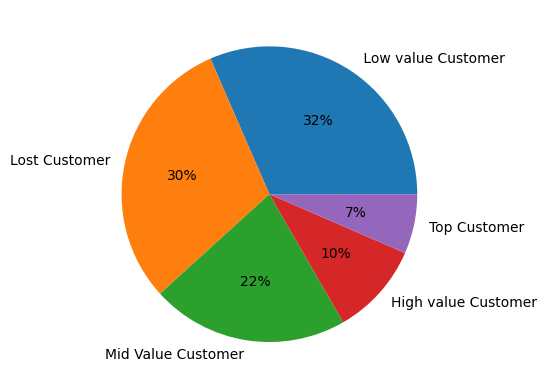

In [81]:
from matplotlib import pyplot as plt
plt.pie(RFM_df['Customer Segment'].value_counts(),
       labels=RFM_df['Customer Segment'].value_counts().index,
       autopct='%.0f%%')
plt.show()